In [1]:

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

In [2]:
df = sns.load_dataset('titanic')
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [3]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [4]:
df.dtypes

survived          int64
pclass            int64
sex                 str
age             float64
sibsp             int64
parch             int64
fare            float64
embarked            str
class          category
who                 str
adult_male         bool
deck           category
embark_town         str
alive               str
alone              bool
dtype: object

In [5]:
categories = df.select_dtypes(include=['str','category']).columns.to_list()
numeric = df.select_dtypes(include=['float64','int64']).columns.to_list()
binary = df.select_dtypes(include=['bool']).columns.to_list()
print(categories)
print(numeric)
print(binary)

['sex', 'embarked', 'class', 'who', 'deck', 'embark_town', 'alive']
['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']
['adult_male', 'alone']


In [6]:
df.age

0      22.0
1      38.0
2      26.0
3      35.0
4      35.0
       ... 
886    27.0
887    19.0
888     NaN
889    26.0
890    32.0
Name: age, Length: 891, dtype: float64

In [7]:
df.deck

0      NaN
1        C
2      NaN
3        C
4      NaN
      ... 
886    NaN
887      B
888    NaN
889      C
890    NaN
Name: deck, Length: 891, dtype: category
Categories (7, str): ['A', 'B', 'C', 'D', 'E', 'F', 'G']

In [8]:
df.embark_town

0      Southampton
1        Cherbourg
2      Southampton
3      Southampton
4      Southampton
          ...     
886    Southampton
887    Southampton
888    Southampton
889      Cherbourg
890     Queenstown
Name: embark_town, Length: 891, dtype: str

In [9]:
df.embarked

0      S
1      C
2      S
3      S
4      S
      ..
886    S
887    S
888    S
889    C
890    Q
Name: embarked, Length: 891, dtype: str

In [11]:
df.fillna(
    {'age':df.age.mean(),
    'deck':df.deck.mode()[0],
    'embark_town':df.embark_town.mode()[0],
    'embarked':df.embarked.mode()[0]},
    inplace=True
)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.000000,1,0,7.2500,S,Third,man,True,C,Southampton,no,False
1,1,1,female,38.000000,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.000000,0,0,7.9250,S,Third,woman,False,C,Southampton,yes,True
3,1,1,female,35.000000,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.000000,0,0,8.0500,S,Third,man,True,C,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.000000,0,0,13.0000,S,Second,man,True,C,Southampton,no,True
887,1,1,female,19.000000,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,29.699118,1,2,23.4500,S,Third,woman,False,C,Southampton,no,False
889,1,1,male,26.000000,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [12]:
df.isnull().sum().sum()

np.int64(0)

In [13]:
df.describe(include='object')

,sex,embarked,who,embark_town,alive
count,891,891,891,891,891
unique,2,3,3,3,2
top,male,S,man,Southampton,no
freq,577,646,537,646,549


Text(0.5, 1.0, 'Fare Distribution for each passenger')

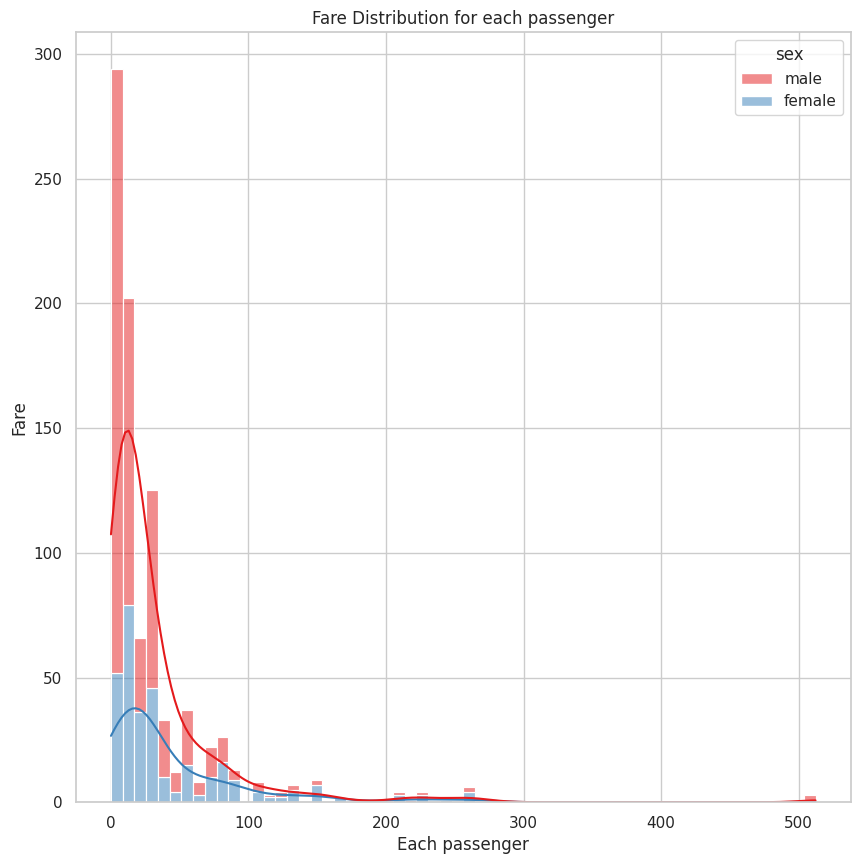

In [22]:
plt.figure(figsize=(10,10))
sns.set_theme(style='whitegrid')
sns.histplot(data=df , x = 'fare' , palette='Set1' , 
             hue = 'sex' , multiple='stack' , kde = True)
plt.xlabel('Each passenger')
plt.ylabel('Fare')
plt.title('Fare Distribution for each passenger')

<Axes: xlabel='sex', ylabel='count'>

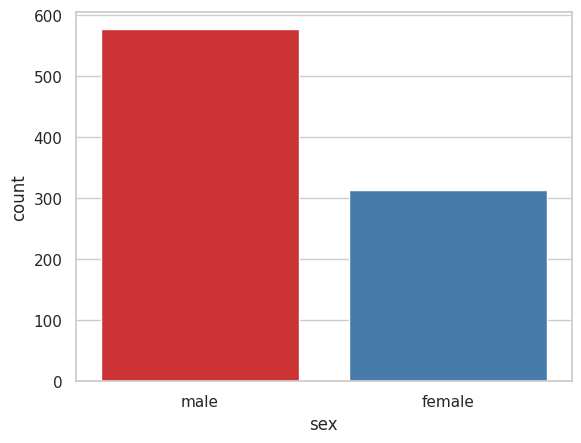

In [24]:
sns.countplot(data=df,x='sex',palette='Set1')

<Axes: xlabel='class', ylabel='fare'>

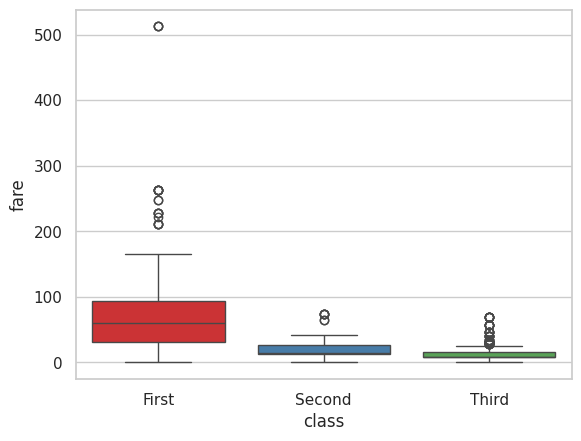

In [25]:
sns.boxplot(data=df,x='class',y='fare',palette='Set1')

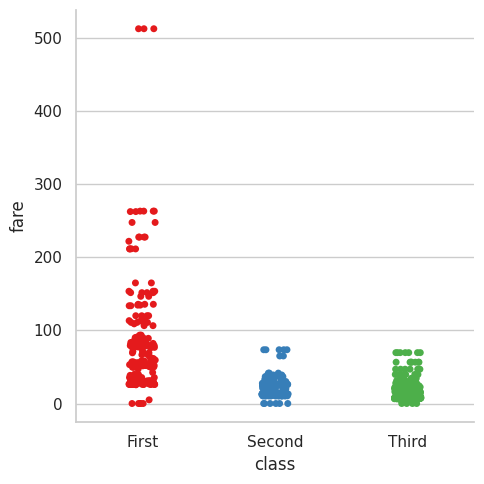

In [28]:
sns.catplot(x='class',y='fare',data=df,kind='strip',palette='Set1')

<Axes: >

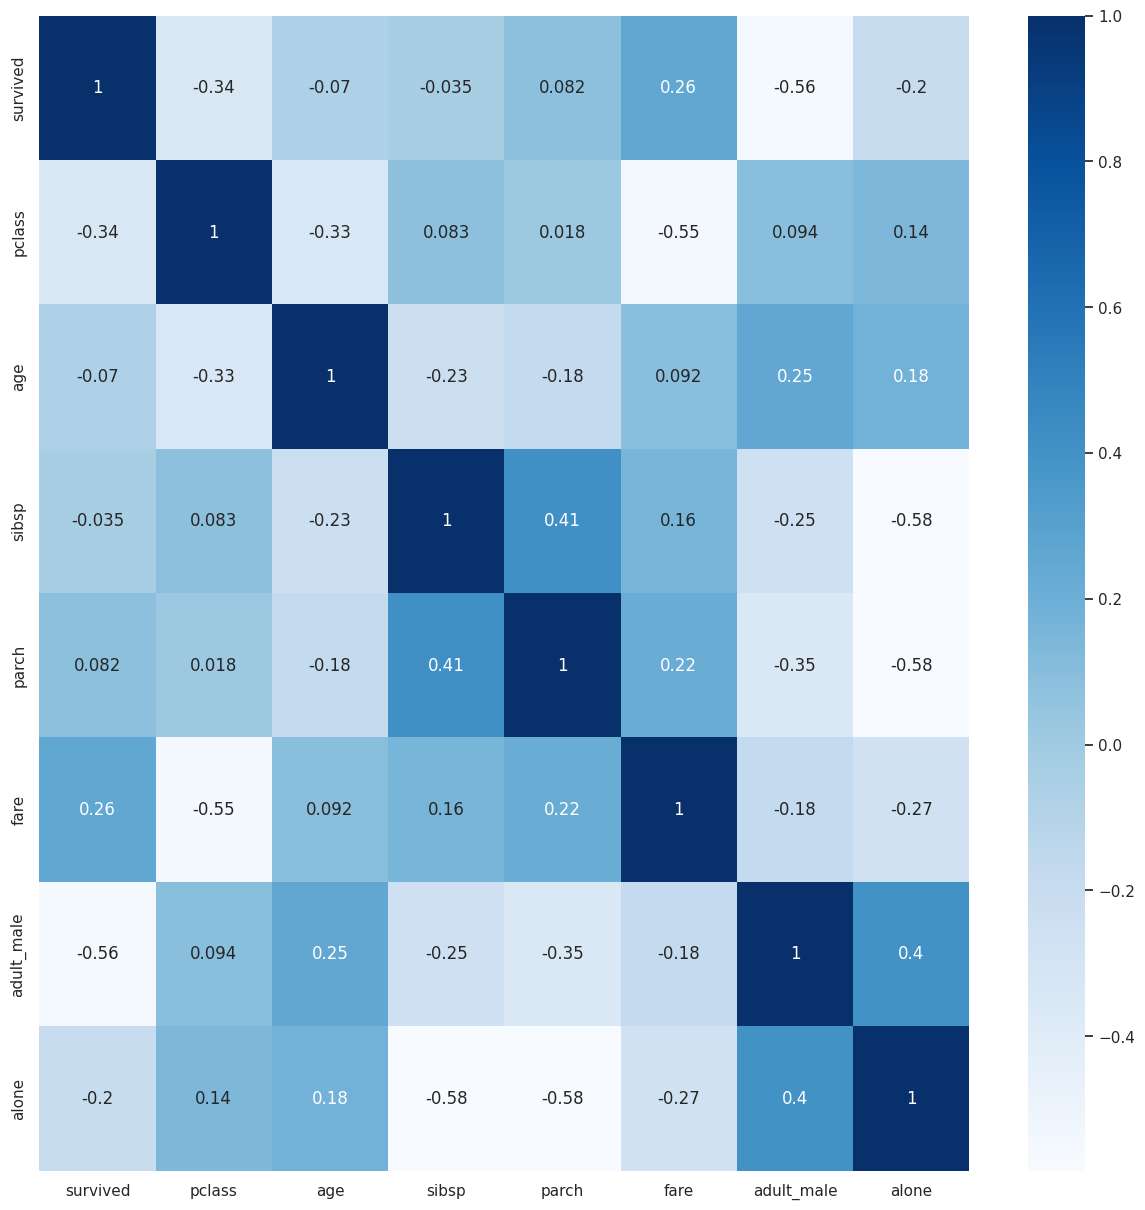

In [30]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(15,15))
sns.heatmap(corr,annot=True,cmap='Blues')